# Name: Gaurav Santosh Bhore
# Rollno 7 , Batch 1 
# Date : 25/2/26
# ML EXP 6 
# Expt.-6: Classification of Credit Card Default Risk using Support Vector Machine

In [13]:
data = pd.read_csv("credit.csv", skiprows=1)
data = data.sample(5000, random_state=42)
print(data.columns)
data.drop(columns=['ID'], inplace=True)
print(data.columns)


Index(['ID', 'LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')
Index(['LIMIT_BAL', 'GENDER', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')


In [17]:
print(data.shape)
print(data.info())


(5000, 24)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 2308 to 4110
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   5000 non-null   int64
 1   GENDER                      5000 non-null   int64
 2   EDUCATION                   5000 non-null   int64
 3   MARRIAGE                    5000 non-null   int64
 4   AGE                         5000 non-null   int64
 5   PAY_0                       5000 non-null   int64
 6   PAY_2                       5000 non-null   int64
 7   PAY_3                       5000 non-null   int64
 8   PAY_4                       5000 non-null   int64
 9   PAY_5                       5000 non-null   int64
 10  PAY_6                       5000 non-null   int64
 11  BILL_AMT1                   5000 non-null   int64
 12  BILL_AMT2                   5000 non-null   int64
 13  BILL_AMT3                   5000 non-null   int64

In [18]:
print(data.shape)
print(data.info())
print(data.head())
print(data.isnull().sum())

(5000, 24)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 2308 to 4110
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   5000 non-null   int64
 1   GENDER                      5000 non-null   int64
 2   EDUCATION                   5000 non-null   int64
 3   MARRIAGE                    5000 non-null   int64
 4   AGE                         5000 non-null   int64
 5   PAY_0                       5000 non-null   int64
 6   PAY_2                       5000 non-null   int64
 7   PAY_3                       5000 non-null   int64
 8   PAY_4                       5000 non-null   int64
 9   PAY_5                       5000 non-null   int64
 10  PAY_6                       5000 non-null   int64
 11  BILL_AMT1                   5000 non-null   int64
 12  BILL_AMT2                   5000 non-null   int64
 13  BILL_AMT3                   5000 non-null   int64

In [20]:
y= data['default payment next month']
x= data[['BILL_AMT1','BILL_AMT2']]
print(x.dtypes)
print(x.head())

BILL_AMT1    int64
BILL_AMT2    int64
dtype: object
       BILL_AMT1  BILL_AMT2
2308        8864      10062
22404     136736     125651
23397      70122      69080
25058      20678      18956
2664       94228      47635


In [23]:
x_train,x_test,y_train,y_test= train_test_split(x,y ,test_size=0.3,random_state=42)

In [24]:
scaler= StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [34]:
models = {
    "Linear SVM ": SVC(kernel='linear', C= 1, class_weight='balanced'),
    "Polynomial SVM" : SVC (kernel='poly',
                           degree=2,
                            C=1,gamma='scale',
                            class_weight='balanced'
                        ),
    "RBF SVM" : SVC(kernel = 'rbf',
                    C=5,
                    gamma = 0.1,
                    class_weight = 'balanced'
                   )
}

for name, model in models.items():
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    y_pred_train = model.predict(x_train)

    print("\n",name)
    print("Confusion Matrix",confusion_matrix(y_test,y_pred))
    print("precision score",precision_score(y_test,y_pred, zero_division=0))
    print("recall score",recall_score(y_test,y_pred))
    print("f1 score",f1_score(y_test,y_pred))
    print("Accuracy score :", accuracy_score(y_test , y_pred))
    print("Accuracy score :", accuracy_score(y_train , y_pred_train))
    


 Linear SVM 
Confusion Matrix [[ 103 1056]
 [  34  307]]
precision score 0.2252384446074835
recall score 0.9002932551319648
f1 score 0.36032863849765256
Accuracy score : 0.2733333333333333
Accuracy score : 0.2797142857142857

 Polynomial SVM
Confusion Matrix [[  35 1124]
 [   8  333]]
precision score 0.22855181880576528
recall score 0.9765395894428153
f1 score 0.3704115684093437
Accuracy score : 0.24533333333333332
Accuracy score : 0.24114285714285713

 RBF SVM
Confusion Matrix [[560 599]
 [166 175]]
precision score 0.22609819121447028
recall score 0.5131964809384164
f1 score 0.3139013452914798
Accuracy score : 0.49
Accuracy score : 0.5017142857142857


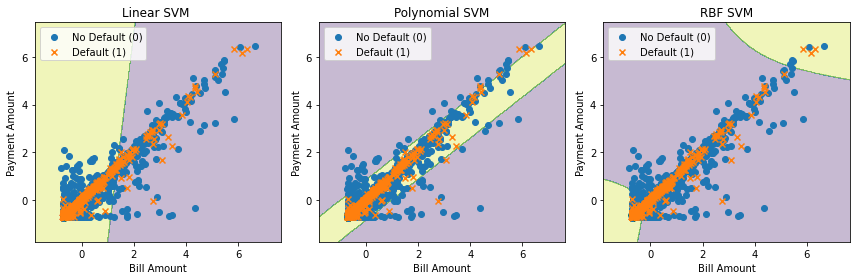

In [43]:
def plot_boundary(model, title):
    h = 0.02
    x_min, x_max = x_train[:, 0].min() - 1, x_train[:, 0].max() + 1
    y_min, y_max = x_train[:, 1].min() - 1, x_train[:, 1].max() + 1
   
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
   
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
   
    plt.contourf(xx, yy, Z, alpha=0.3)
   
    plt.scatter(x_train[y_train == 0, 0],
                x_train[y_train == 0, 1],
                label='No Default (0)',
                marker='o')
   
    plt.scatter(x_train[y_train == 1, 0],
                x_train[y_train == 1, 1],
                label='Default (1)',
                marker='x')
   
    plt.legend()
    plt.title(title)
    plt.xlabel("Bill Amount")
    plt.ylabel("Payment Amount")

plt.figure(figsize=(12, 4))

for i, (name, model) in enumerate(models.items()):
    plt.subplot(1,3,i+1)
    model.fit(x_train, y_train)
    plot_boundary(model, name)

plt.tight_layout()
plt.show()